# Pipeline ML — CO₂ per capita (Árvore + SVM)

**Trabalho:** Previsão de emissão de CO₂ per capita por país (2000–2026)  
**Objetivo:** Treinar modelos supervisionados e prever o valor para **2027**

Este notebook executa o pipeline completo em 4 etapas:

| Etapa | Script | Descrição |
|-------|--------|-----------|
| 1 | `step1_prepare.py` | Download/preparação dos dados e features temporais |
| 2 | `step2_train.py` | Treinamento paralelo (Árvore + SVM) por país |
| 3 | `step3_report.py` | Relatórios consolidados e gráficos |
| 4 | `step4_predict_2027.py` | Previsão de CO₂ per capita para 2027 |

> **Fonte dos dados:** [Planilha Google Sheets](https://docs.google.com/spreadsheets/d/1CGX7KrvTQ6qM95EFzDsAMSynA7rgDbR5RsCzdTAJpZw/edit)

## 0. Instalação de dependências

Execute esta célula primeiro. No Google Colab, as bibliotecas base já vêm instaladas; aqui garantimos todas as dependências do projeto.

In [1]:
# Detecta ambiente Colab vs local
try:
    import google.colab  # type: ignore
    IN_COLAB = True
    print("Ambiente: Google Colab")
except ImportError:
    IN_COLAB = False
    print("Ambiente: local / Jupyter")

if IN_COLAB:
    # Descomente e ajuste se o projeto estiver no Drive ou for clonado do Git:
    # from google.colab import drive
    # drive.mount('/content/drive')
    # %cd /content/drive/MyDrive/2bi_trabalho_co2-pib
    pass

!pip install -q pandas numpy scikit-learn joblib openpyxl matplotlib seaborn tqdm requests

Ambiente: local / Jupyter
error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint:

## 0.1 Configuração e imports

Ajuste `SELECTED_MODEL` antes de executar a Etapa 4 (`"tree"` ou `"svm"`).

In [2]:
import logging
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Raiz do projeto (pasta onde estão step1_prepare.py, utils/, etc.)
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "step1_prepare.py").exists():
    # Fallback: notebook pode estar em subpasta
    for candidate in [Path.cwd(), Path.cwd().parent]:
        if (candidate / "step1_prepare.py").exists():
            PROJECT_ROOT = candidate
            break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline

from utils.logging_config import setup_logging
from step1_prepare import run as run_step1
from step2_train import run as run_step2
from step3_report import run as run_step3
from step4_predict_2027 import run as run_step4

setup_logging(PROJECT_ROOT / "logs" / "pipeline.log")
logging.getLogger().setLevel(logging.INFO)

# Modelo usado na previsão de 2027
SELECTED_MODEL = "svm"  # opções: "tree" ou "svm"

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"

print(f"Projeto: {PROJECT_ROOT}")
print(f"Modelo selecionado para 2027: {SELECTED_MODEL}")

Projeto: /mnt/Dados/Facul/IA/2bi_trabalho_co2-pib
Modelo selecionado para 2027: svm


---
## Etapa 1 — Preparação dos dados

- Baixa a planilha do Google Sheets (ou usa `data/dataset.csv` local)
- Detecta colunas: país, ano, CO₂ per capita
- Gera features temporais: `lag_1`, `lag_2`, `lag_3`, `rolling_mean_3`, `rolling_mean_5`, `growth_rate`
- Split temporal **80% treino / 20% teste** (sem embaralhar)
- Salva um CSV por país em `data/processed/`

In [3]:
country_tables = run_step1()

processed_files = sorted(PROCESSED_DIR.glob("*.csv"))
print(f"\nPaíses processados: {len(processed_files)}")
print(f"Dataset bruto: {DATA_DIR / 'dataset.csv'}")

# Prévia de um país
sample = pd.read_csv(processed_files[0])
country_name = sample["country"].iloc[0]
print(f"\nPrévia — {country_name} ({processed_files[0].name}):")
display(sample.head())
display(sample[["year", "co2_per_capita", "lag_1", "rolling_mean_3", "split"]].tail())

2026-06-13 16:51:05 [INFO] utils.io: Tentativa 1/3: baixando dados de https://docs.google.com/spreadsheets/d/1CGX7KrvTQ6qM95EFzDsAMSynA7rgDbR5RsCzdTAJpZw/export?format=csv
2026-06-13 16:51:05 [INFO] utils.io: Dataset salvo em /mnt/Dados/Facul/IA/2bi_trabalho_co2-pib/data/dataset.csv (63718 bytes)
2026-06-13 16:51:05 [INFO] utils.io: Dataset baixado e carregado (1350 linhas)
2026-06-13 16:51:05 [INFO] step1_prepare: Fonte dos dados: /mnt/Dados/Facul/IA/2bi_trabalho_co2-pib/data/dataset.csv
2026-06-13 16:51:05 [INFO] utils.columns: Colunas detectadas — país: country, ano: year, CO₂: co2_per_capita_t
2026-06-13 16:51:05 [INFO] step1_prepare: Período dos dados: 2000–2026
2026-06-13 16:51:06 [INFO] step1_prepare: Total de países identificados: 50
2026-06-13 16:51:06 [INFO] step1_prepare: País 'Algeria' salvo em algeria.csv (23 linhas, treino=18, teste=5)
2026-06-13 16:51:06 [INFO] step1_prepare: País 'Argentina' salvo em argentina.csv (23 linhas, treino=18, teste=5)
2026-06-13 16:51:06 [INF


Países processados: 50
Dataset bruto: /mnt/Dados/Facul/IA/2bi_trabalho_co2-pib/data/dataset.csv

Prévia — Algeria (algeria.csv):


,year,country,iso3,region,co2_emissions_mt,population_millions,co2_per_capita,co2_intensity_kg_per_gdp_usd,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_5,growth_rate,split
0,2004,Algeria,DZA,MENA,111.1,39.5,2.82,0.40,2.76,2.71,2.67,2.763333,2.726,0.021739,train
1,2005,Algeria,DZA,MENA,112.6,39.8,2.83,0.38,2.82,2.76,2.71,2.803333,2.758,0.003546,train
2,2006,Algeria,DZA,MENA,116.7,40.1,2.91,0.36,2.83,2.82,2.76,2.853333,2.806,0.028269,train
3,2007,Algeria,DZA,MENA,123.7,40.4,3.07,0.36,2.91,2.83,2.82,2.936667,2.878,0.054983,train
4,2008,Algeria,DZA,MENA,123.6,40.7,3.04,0.34,3.07,2.91,2.83,3.006667,2.934,-0.009772,train


,year,co2_per_capita,lag_1,rolling_mean_3,split
18,2022,4.14,3.95,3.993333,test
19,2023,4.31,4.14,4.133333,test
20,2024,4.30,4.31,4.250000,test
21,2025,4.22,4.30,4.276667,test
22,2026,4.35,4.22,4.290000,test


---
## Etapa 2 — Treinamento (Árvore + SVM)

Para **cada país**, em paralelo:

| Modelo | Algoritmo | Hiperparâmetros testados |
|--------|-----------|--------------------------|
| Árvore | `DecisionTreeRegressor` | `max_depth`, `min_samples_leaf` |
| SVM | `SVR` + `StandardScaler` | `kernel`, `C`, `gamma`, `epsilon` |

Métricas no conjunto de **teste**: MAE, MSE, RMSE, R², MAPE.

Modelos persistidos em `models/tree/` e `models/svm/` (joblib). Se os dados não mudaram, modelos existentes são reutilizados.

In [4]:
train_results = run_step2(max_workers=8)

metrics_df = pd.read_csv(REPORTS_DIR / "metrics.csv")
trained = sum(1 for r in train_results if not r.error and not r.skipped)
skipped = sum(1 for r in train_results if r.skipped)
errors = sum(1 for r in train_results if r.error)

print(f"\nTreinamentos novos: {trained}")
print(f"Modelos reutilizados: {skipped}")
print(f"Erros: {errors}")
print(f"\nMétricas ({len(metrics_df)} registros):")
display(metrics_df.head(10))

Treinando países:   0%|                                                                                                          | 0/50 [00:00<?, ?it/s]2026-06-13 16:51:06 [INFO] utils.persistence: Modelo tree/algeria carregado (sem retreino)
2026-06-13 16:51:06 [INFO] utils.persistence: Modelo tree/belgium carregado (sem retreino)
2026-06-13 16:51:06 [INFO] utils.persistence: Modelo tree/brazil carregado (sem retreino)
2026-06-13 16:51:06 [INFO] utils.persistence: Modelo tree/bangladesh carregado (sem retreino)
2026-06-13 16:51:06 [INFO] utils.persistence: Modelo tree/australia carregado (sem retreino)
2026-06-13 16:51:06 [INFO] utils.persistence: Modelo tree/argentina carregado (sem retreino)
2026-06-13 16:51:06 [INFO] utils.persistence: Modelo tree/canada carregado (sem retreino)
2026-06-13 16:51:06 [INFO] utils.persistence: Modelo tree/chile carregado (sem retreino)
2026-06-13 16:51:06 [INFO] utils.persistence: Modelo svm/algeria carregado (sem retreino)
2026-06-13 16:51:06 [INFO] 


Treinamentos novos: 0
Modelos reutilizados: 100
Erros: 0

Métricas (100 registros):


,country,model,mae,mse,rmse,r2,mape
0,Algeria,tree,0.331000,0.115045,0.339183,-19.456081,7.735656
1,Algeria,svm,0.020200,0.000639,0.025278,0.886380,0.472971
2,Brazil,tree,0.059556,0.005226,0.072289,-1.107129,2.798059
3,Brazil,svm,0.014587,0.000248,0.015763,0.899815,0.689903
4,Belgium,tree,0.415000,0.267425,0.517132,-1.809086,5.963596
5,Belgium,svm,0.012174,0.000229,0.015121,0.997598,0.166058
6,Bangladesh,tree,0.084000,0.009120,0.095499,-3.418605,11.393736
7,Bangladesh,svm,0.016053,0.000328,0.018115,0.841004,2.225937
8,Australia,tree,0.281500,0.119686,0.345957,-0.000922,1.980006
9,Australia,svm,0.025735,0.000757,0.027522,0.993666,0.178184


---
## Etapa 3 — Relatórios consolidados

Gera:
- `country_summary.csv` / `.xlsx` — R² e métricas por país
- `best_by_country.csv` — melhor modelo por país
- `ranking.csv` — vitórias globais por modelo
- `summary.txt` — resumo textual
- Gráficos em `reports/figures/`

In [5]:
run_step3()

summary_df = pd.read_csv(REPORTS_DIR / "country_summary.csv")
best_df = pd.read_csv(REPORTS_DIR / "best_by_country.csv")
ranking_df = pd.read_csv(REPORTS_DIR / "ranking.csv")

print("=== Country Summary (R²) ===")
display(summary_df[["country", "tree_r2", "svm_r2"]].head(15))

print("\n=== Melhor modelo por país ===")
display(best_df.head(15))

print("\n=== Ranking global ===")
display(ranking_df)

summary_text = (REPORTS_DIR / "summary.txt").read_text(encoding="utf-8")
print("\n=== Resumo textual ===")
print(summary_text)

2026-06-13 16:51:07 [INFO] step3_report: Relatórios Excel salvos: /mnt/Dados/Facul/IA/2bi_trabalho_co2-pib/reports/metrics.xlsx, /mnt/Dados/Facul/IA/2bi_trabalho_co2-pib/reports/country_summary.xlsx
2026-06-13 16:51:07 [INFO] step3_report: Resumo textual salvo em /mnt/Dados/Facul/IA/2bi_trabalho_co2-pib/reports/summary.txt
2026-06-13 16:51:09 [INFO] step3_report: Figuras salvas em /mnt/Dados/Facul/IA/2bi_trabalho_co2-pib/reports/figures
2026-06-13 16:51:09 [INFO] step3_report: Relatório consolidado: 50 países, ranking SVM=50, Árvore=0


=== Country Summary (R²) ===


,country,tree_r2,svm_r2
0,Algeria,-19.456081,0.886380
1,Argentina,-0.145474,0.844431
2,Australia,-0.000922,0.993666
3,Bangladesh,-3.418605,0.841004
4,Belgium,-1.809086,0.997598
5,Brazil,-1.107129,0.899815
6,Canada,-13.227628,0.849272
7,Chile,-2.304143,0.965694
8,China,-19.407654,0.775164
9,Colombia,-0.004673,0.557445



=== Melhor modelo por país ===


,country,best_model,best_model_label,best_r2
0,Algeria,svm,SVM,0.886380
1,Argentina,svm,SVM,0.844431
2,Australia,svm,SVM,0.993666
3,Bangladesh,svm,SVM,0.841004
4,Belgium,svm,SVM,0.997598
5,Brazil,svm,SVM,0.899815
6,Canada,svm,SVM,0.849272
7,Chile,svm,SVM,0.965694
8,China,svm,SVM,0.775164
9,Colombia,svm,SVM,0.557445



=== Ranking global ===


,model,model_label,wins
0,tree,Árvore,0
1,svm,SVM,50



=== Resumo textual ===
SVM apresentou melhor desempenho em 50 países.
Árvore apresentou melhor desempenho em 0 países.
SVM foi o modelo superior na maioria dos cenários.



r2_by_country.png


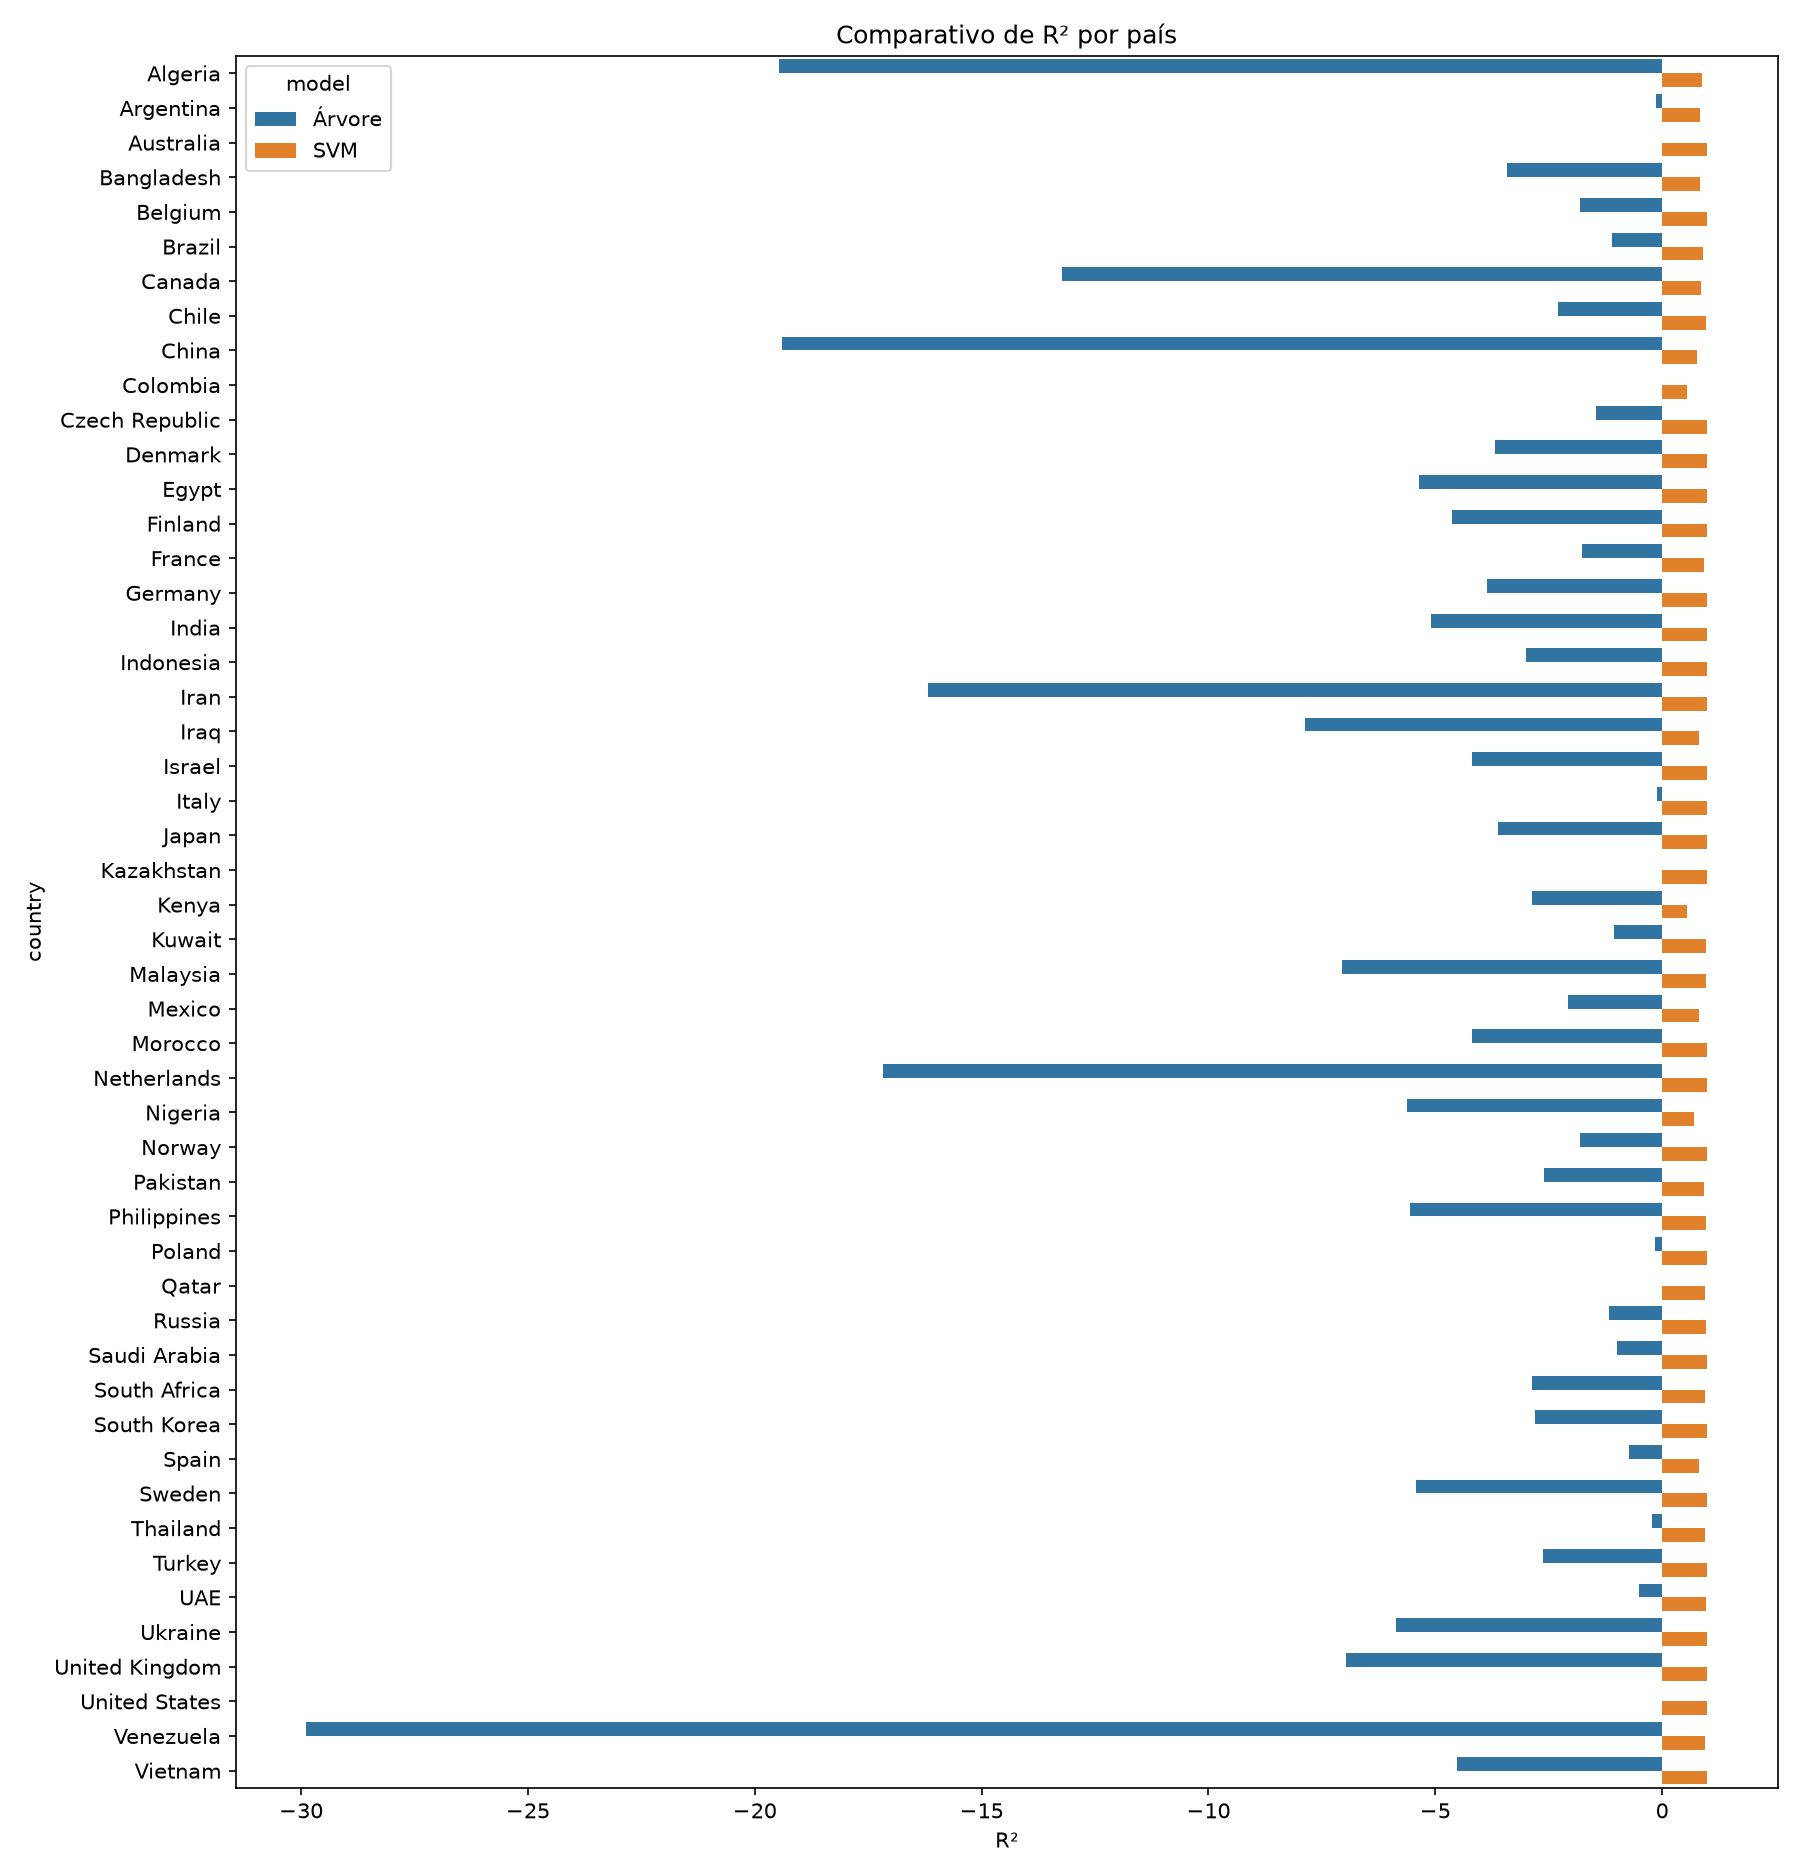

tree_vs_svm_scatter.png


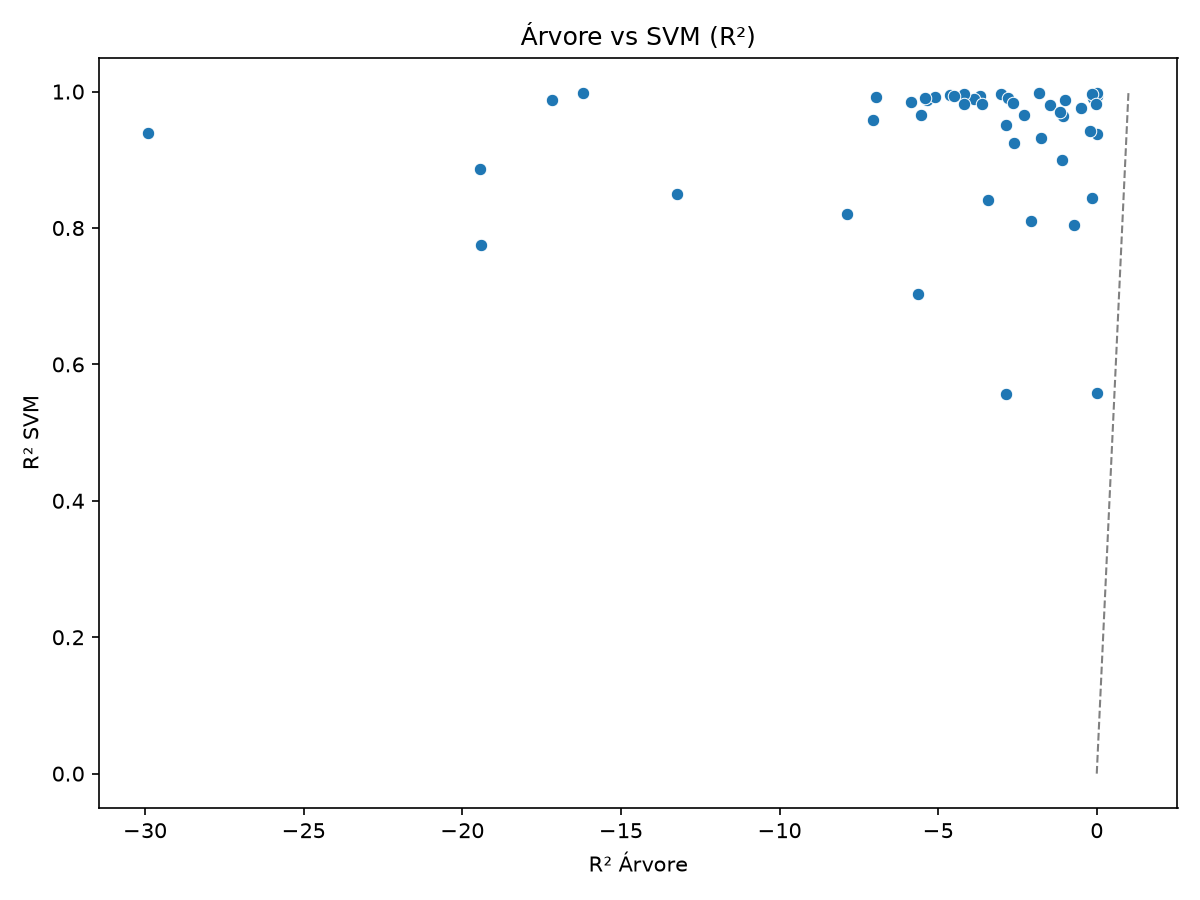

In [6]:
# Gráficos gerados pelo step3
figures = sorted((REPORTS_DIR / "figures").glob("*.png"))
if figures:
    for fig_path in figures:
        print(fig_path.name)
        display(Image(filename=str(fig_path)))
else:
    print("Nenhuma figura encontrada em reports/figures/")

---
## Etapa 4 — Previsão CO₂ per capita 2027

Usa o modelo definido em `SELECTED_MODEL` (`"tree"` ou `"svm"`).

Para cada país:
1. Carrega histórico até 2026
2. Monta features temporais de 2027
3. Gera previsão

Resultado salvo em `reports/predictions_2027.csv` e `.xlsx`.

In [7]:
predictions_df = run_step4(model_type=SELECTED_MODEL)

print(f"Previsões geradas com modelo: {SELECTED_MODEL.upper()}")
print(f"Total de países: {len(predictions_df)}\n")

display(
    predictions_df.sort_values("co2_predicted_2027", ascending=False)
    .head(15)
    .style.format({"co2_2026": "{:.2f}", "co2_predicted_2027": "{:.4f}"})
)

print("\nPaíses com menor emissão prevista em 2027:")
display(
    predictions_df.sort_values("co2_predicted_2027")
    .head(10)
    .style.format({"co2_2026": "{:.2f}", "co2_predicted_2027": "{:.4f}"})
)

2026-06-13 16:51:09 [INFO] step4_predict_2027: Previsões 2027 (svm) salvas: 50 países em /mnt/Dados/Facul/IA/2bi_trabalho_co2-pib/reports/predictions_2027.csv


Previsões geradas com modelo: SVM
Total de países: 50



,country,co2_2026,co2_predicted_2027,model
35,Qatar,37.90,38.3722,svm
44,UAE,24.06,24.1326,svm
25,Kuwait,21.68,22.8116,svm
37,Saudi Arabia,17.78,17.8763,svm
47,United States,13.97,14.0279,svm
23,Kazakhstan,13.91,14.0081,svm
6,Canada,13.87,13.8825,svm
2,Australia,13.78,13.6335,svm
36,Russia,12.44,12.3386,svm
39,South Korea,11.07,10.9289,svm



Países com menor emissão prevista em 2027:


,country,co2_2026,co2_predicted_2027,model
24,Kenya,0.48,0.4602,svm
30,Nigeria,0.65,0.6485,svm
3,Bangladesh,0.76,0.7582,svm
32,Pakistan,1.20,1.2003,svm
33,Philippines,1.55,1.5802,svm
9,Colombia,1.74,1.7381,svm
5,Brazil,2.11,2.0697,svm
28,Morocco,2.12,2.1268,svm
16,India,2.13,2.1631,svm
41,Sweden,2.60,2.5944,svm


---
## Visualização — Top 10 países (2026 vs 2027 previsto)

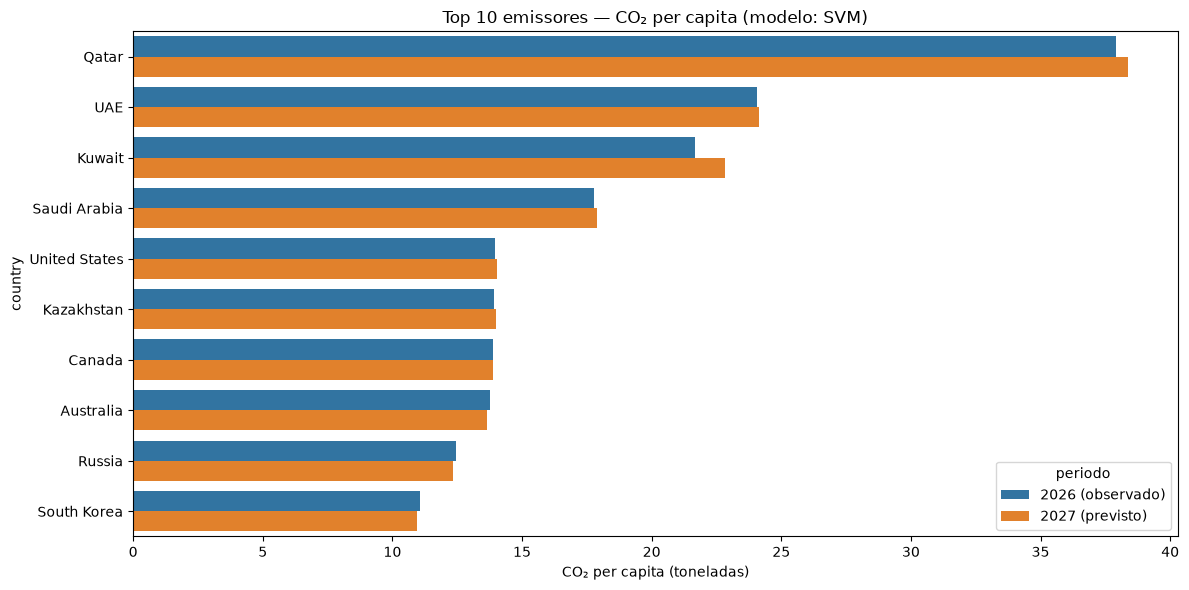

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = predictions_df.nlargest(10, "co2_predicted_2027")
plot_df = top10.melt(
    id_vars="country",
    value_vars=["co2_2026", "co2_predicted_2027"],
    var_name="periodo",
    value_name="co2_per_capita",
)
plot_df["periodo"] = plot_df["periodo"].map(
    {"co2_2026": "2026 (observado)", "co2_predicted_2027": "2027 (previsto)"}
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="co2_per_capita", y="country", hue="periodo")
plt.title(f"Top 10 emissores — CO₂ per capita (modelo: {SELECTED_MODEL.upper()})")
plt.xlabel("CO₂ per capita (toneladas)")
plt.tight_layout()
plt.show()

---
## Resumo final do pipeline

Artefatos gerados:

In [9]:
from pathlib import Path

artifacts = {
    "Dados processados": len(list(PROCESSED_DIR.glob("*.csv"))),
    "Modelos Árvore": len(list((MODELS_DIR / "tree").glob("*.joblib"))),
    "Modelos SVM": len(list((MODELS_DIR / "svm").glob("*.joblib"))),
    "Relatórios CSV/XLSX": len(list(REPORTS_DIR.glob("*.*"))),
}

print("Pipeline concluído!\n")
for name, count in artifacts.items():
    print(f"  • {name}: {count}")

print("\nArquivos principais:")
for path in sorted(REPORTS_DIR.glob("*")):
    if path.is_file():
        print(f"  → {path.relative_to(PROJECT_ROOT)}")

Pipeline concluído!

  • Dados processados: 50
  • Modelos Árvore: 50
  • Modelos SVM: 50
  • Relatórios CSV/XLSX: 9

Arquivos principais:
  → reports/best_by_country.csv
  → reports/country_summary.csv
  → reports/country_summary.xlsx
  → reports/metrics.csv
  → reports/metrics.xlsx
  → reports/predictions_2027.csv
  → reports/predictions_2027.xlsx
  → reports/ranking.csv
  → reports/summary.txt
